In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

In [3]:
# Load all comp2 experiments
output_dir = Path("../output")

# Find all comp2 experiments
comp2_experiments = sorted([d.name for d in output_dir.iterdir() 
                           if d.is_dir() and d.name.startswith("comp2")])

print(f"Found {len(comp2_experiments)} comp2 experiments:")
for exp in comp2_experiments:
    print(f"  - {exp}")

Found 5 comp2 experiments:
  - comp2_entrega1_202108_zlgbm
  - comp2_entrega2_202108_under0.05_zlgbm
  - comp2_entrega2_test202106_under0.05_zlgbm
  - comp2_entrega3_202108_under0.1_zlgbm
  - comp2_entrega4_202108_under0.05_zero_zlgbm


In [4]:
# Load feature importance for each experiment
feature_importances = {}

for exp in comp2_experiments:
    fi_file = output_dir / exp / "feature_importance.txt"
    if fi_file.exists():
        df = pl.read_csv(fi_file, separator="\t")
        feature_importances[exp] = df
        print(f"✓ {exp}: {len(df)} features")
    else:
        print(f"✗ {exp}: feature_importance.txt not found")

print(f"\nLoaded {len(feature_importances)} experiments")


✓ comp2_entrega1_202108_zlgbm: 2752 features
✓ comp2_entrega2_202108_under0.05_zlgbm: 2752 features
✓ comp2_entrega2_test202106_under0.05_zlgbm: 2752 features
✓ comp2_entrega3_202108_under0.1_zlgbm: 2752 features
✓ comp2_entrega4_202108_under0.05_zero_zlgbm: 2752 features

Loaded 5 experiments


In [5]:
# Compare top 20 features across experiments
top_n = 20

print(f"Top {top_n} features by experiment:\n")
print("="*100)

for exp, df in feature_importances.items():
    print(f"\n{exp}:")
    print("-"*100)
    top_features = df.head(top_n)
    for i, row in enumerate(top_features.iter_rows(named=True), 1):
        print(f"  {i:2d}. {row['feature']:<50} {row['importance_pct']:>6.2f}%")
    print(f"\nTop {top_n} cumulative importance: {top_features['importance_pct'].sum():.2f}%")


Top 20 features by experiment:


comp2_entrega1_202108_zlgbm:
----------------------------------------------------------------------------------------------------
   1. rf_009_005                                           8.40%
   2. ctrx_quarter_normalizado                             8.33%
   3. mcaja_ahorro                                         3.17%
   4. rf_016_003                                           2.27%
   5. ctrx_quarter                                         1.73%
   6. mtarjeta_visa_consumo                                1.56%
   7. rf_008_014                                           1.53%
   8. edad_x_mcaja_ahorro                                  1.43%
   9. cpayroll_trx                                         1.30%
  10. mcuenta_corriente                                    1.17%
  11. mpayroll_sobre_edad                                  0.81%
  12. mcuentas_saldo                                       0.79%
  13. ctarjeta_visa_transacciones                        

In [6]:
# Find features that appear in top 20 of ALL experiments
from collections import Counter

all_top_features = []
for exp, df in feature_importances.items():
    top_features = df.head(20)['feature'].to_list()
    all_top_features.extend(top_features)

feature_counts = Counter(all_top_features)
consistent_features = [(feat, count) for feat, count in feature_counts.most_common() 
                       if count == len(feature_importances)]

print(f"\nFeatures that appear in top 20 of ALL {len(feature_importances)} experiments:")
print("="*100)
if consistent_features:
    for feat, count in consistent_features:
        print(f"  - {feat}")
else:
    print("  None (no features are consistently in top 20 across all experiments)")

print(f"\nFeatures that appear in top 20 of at least 3 experiments:")
print("="*100)
frequent_features = [(feat, count) for feat, count in feature_counts.most_common(30) 
                     if count >= 3]
for feat, count in frequent_features:
    print(f"  - {feat:<50} ({count}/{len(feature_importances)} experiments)")



Features that appear in top 20 of ALL 5 experiments:
  - ctrx_quarter_normalizado
  - mcaja_ahorro
  - ctrx_quarter
  - mtarjeta_visa_consumo
  - edad_x_mcaja_ahorro
  - cpayroll_trx
  - mpayroll_sobre_edad
  - mcuentas_saldo

Features that appear in top 20 of at least 3 experiments:
  - ctrx_quarter_normalizado                           (5/5 experiments)
  - mcaja_ahorro                                       (5/5 experiments)
  - ctrx_quarter                                       (5/5 experiments)
  - mtarjeta_visa_consumo                              (5/5 experiments)
  - edad_x_mcaja_ahorro                                (5/5 experiments)
  - cpayroll_trx                                       (5/5 experiments)
  - mpayroll_sobre_edad                                (5/5 experiments)
  - mcuentas_saldo                                     (5/5 experiments)
  - ctarjeta_visa_transacciones                        (4/5 experiments)
  - mpayroll                                           (4

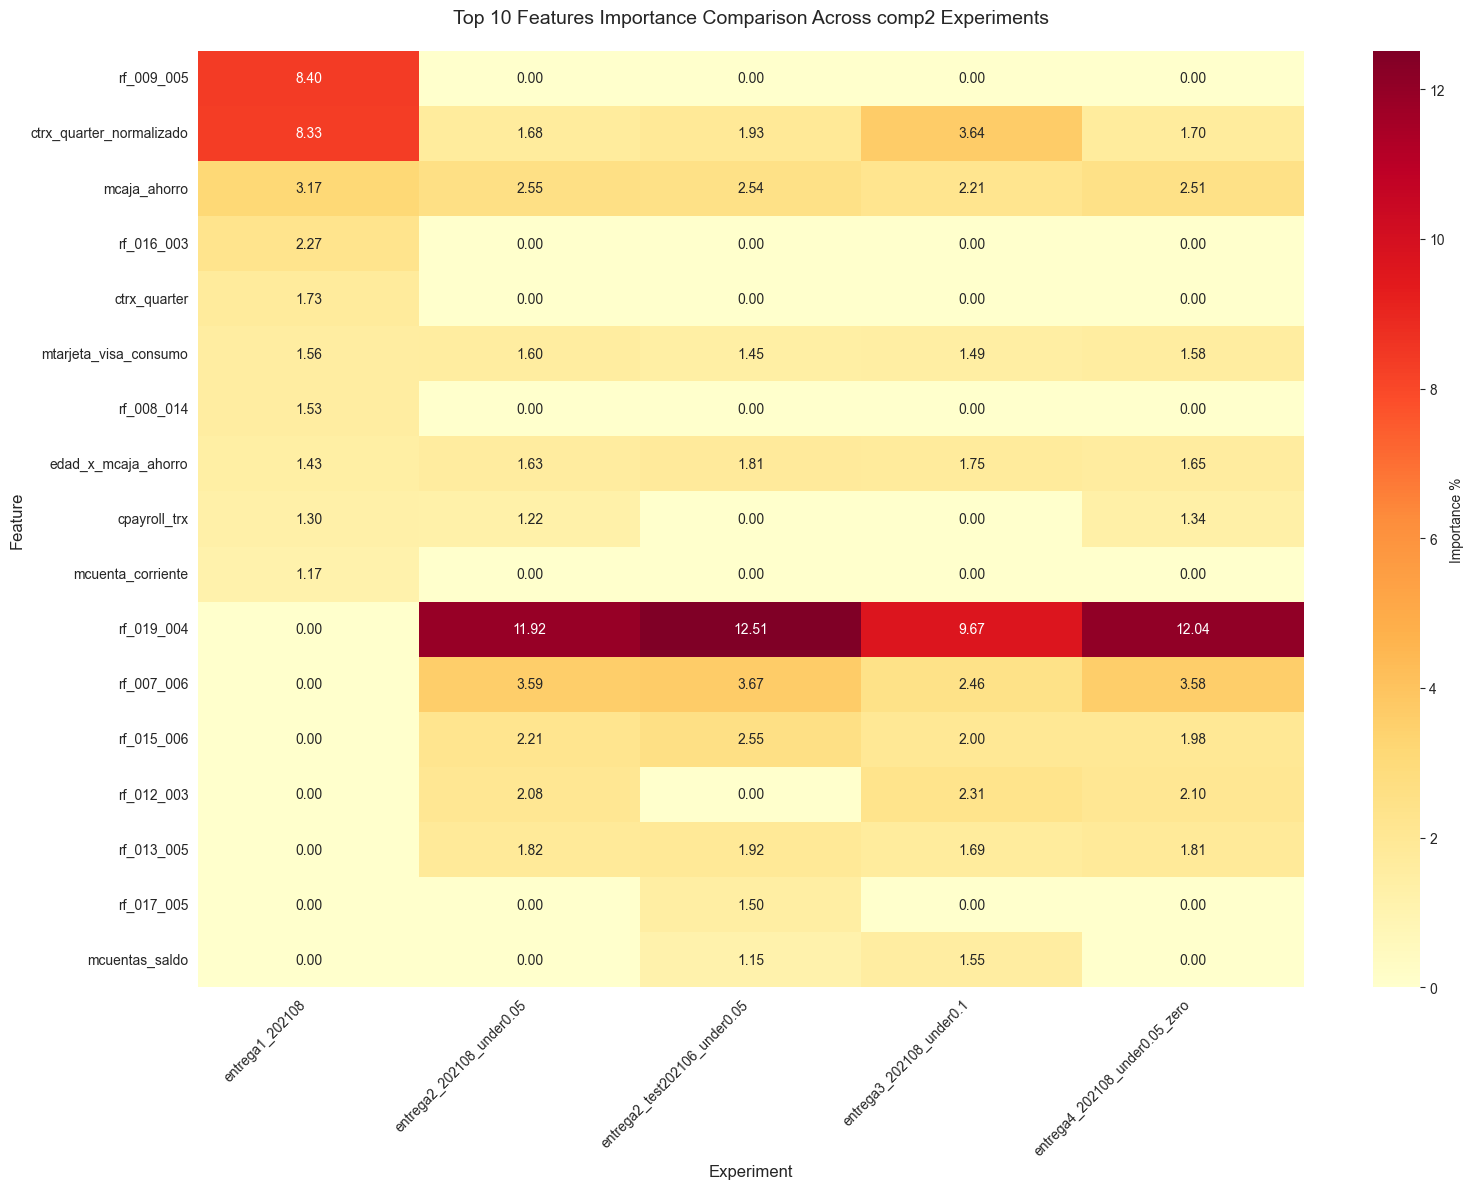

In [7]:
# Visualize top 10 features comparison
import pandas as pd

# Create comparison dataframe
top_10_comparison = {}
for exp, df in feature_importances.items():
    top_10 = df.head(10)
    exp_short = exp.replace("comp2_", "").replace("_zlgbm", "")
    top_10_comparison[exp_short] = dict(zip(top_10['feature'], top_10['importance_pct']))

# Convert to DataFrame for easier plotting
comparison_df = pd.DataFrame(top_10_comparison).fillna(0)

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(comparison_df, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Importance %'})
plt.title('Top 10 Features Importance Comparison Across comp2 Experiments', fontsize=14, pad=20)
plt.xlabel('Experiment', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:
# Compare RF features vs other features
print("RF Features vs Other Features Analysis:")
print("="*100)

for exp, df in feature_importances.items():
    rf_features = df.filter(pl.col('feature').str.starts_with('rf_'))
    other_features = df.filter(~pl.col('feature').str.starts_with('rf_'))
    
    rf_importance = rf_features['importance_pct'].sum()
    other_importance = other_features['importance_pct'].sum()
    
    print(f"\n{exp}:")
    print(f"  RF features:    {len(rf_features):4d} features, {rf_importance:6.2f}% importance")
    print(f"  Other features: {len(other_features):4d} features, {other_importance:6.2f}% importance")
    print(f"  RF in top 10:   {len([f for f in df.head(10)['feature'] if f.startswith('rf_')])} features")
    print(f"  RF in top 20:   {len([f for f in df.head(20)['feature'] if f.startswith('rf_')])} features")


RF Features vs Other Features Analysis:

comp2_entrega1_202108_zlgbm:
  RF features:     320 features,  14.16% importance
  Other features: 2432 features,  85.84% importance
  RF in top 10:   3 features
  RF in top 20:   3 features

comp2_entrega2_202108_under0.05_zlgbm:
  RF features:     320 features,  25.21% importance
  Other features: 2432 features,  74.79% importance
  RF in top 10:   5 features
  RF in top 20:   7 features

comp2_entrega2_test202106_under0.05_zlgbm:
  RF features:     320 features,  25.61% importance
  Other features: 2432 features,  74.39% importance
  RF in top 10:   5 features
  RF in top 20:   7 features

comp2_entrega3_202108_under0.1_zlgbm:
  RF features:     320 features,  21.62% importance
  Other features: 2432 features,  78.38% importance
  RF in top 10:   5 features
  RF in top 20:   7 features

comp2_entrega4_202108_under0.05_zero_zlgbm:
  RF features:     320 features,  25.08% importance
  Other features: 2432 features,  74.92% importance
  RF in to

In [9]:
# Analyze differences between experiments
print("\nKey Differences Between Experiments:")
print("="*100)

# Compare entrega2 vs entrega3 (undersampling 0.05 vs 0.1)
if 'comp2_entrega2_202108_under0.05_zlgbm' in feature_importances and \
   'comp2_entrega3_202108_under0.1_zlgbm' in feature_importances:
    
    df2 = feature_importances['comp2_entrega2_202108_under0.05_zlgbm']
    df3 = feature_importances['comp2_entrega3_202108_under0.1_zlgbm']
    
    print("\nEntrega 2 (under=0.05) vs Entrega 3 (under=0.1):")
    print("-"*100)
    
    top_20_e2 = set(df2.head(20)['feature'])
    top_20_e3 = set(df3.head(20)['feature'])
    
    only_in_e2 = top_20_e2 - top_20_e3
    only_in_e3 = top_20_e3 - top_20_e2
    in_both = top_20_e2 & top_20_e3
    
    print(f"  Features in both top 20: {len(in_both)}")
    print(f"  Only in entrega2 top 20: {len(only_in_e2)}")
    if only_in_e2:
        for feat in only_in_e2:
            print(f"    - {feat}")
    print(f"  Only in entrega3 top 20: {len(only_in_e3)}")
    if only_in_e3:
        for feat in only_in_e3:
            print(f"    - {feat}")

# Compare entrega4 (with zero replacement) vs entrega2
if 'comp2_entrega4_202108_under0.05_zero_zlgbm' in feature_importances and \
   'comp2_entrega2_202108_under0.05_zlgbm' in feature_importances:
    
    df4 = feature_importances['comp2_entrega4_202108_under0.05_zero_zlgbm']
    df2 = feature_importances['comp2_entrega2_202108_under0.05_zlgbm']
    
    print("\n\nEntrega 2 (normal) vs Entrega 4 (zero→null replacement):")
    print("-"*100)
    
    top_20_e2 = set(df2.head(20)['feature'])
    top_20_e4 = set(df4.head(20)['feature'])
    
    only_in_e2 = top_20_e2 - top_20_e4
    only_in_e4 = top_20_e4 - top_20_e2
    in_both = top_20_e2 & top_20_e4
    
    print(f"  Features in both top 20: {len(in_both)}")
    print(f"  Only in entrega2 top 20: {len(only_in_e2)}")
    if only_in_e2:
        for feat in only_in_e2:
            print(f"    - {feat}")
    print(f"  Only in entrega4 top 20: {len(only_in_e4)}")
    if only_in_e4:
        for feat in only_in_e4:
            print(f"    - {feat}")



Key Differences Between Experiments:

Entrega 2 (under=0.05) vs Entrega 3 (under=0.1):
----------------------------------------------------------------------------------------------------
  Features in both top 20: 17
  Only in entrega2 top 20: 3
    - rf_014_003
    - ctarjeta_visa_transacciones_ratioavg6
    - ctarjeta_visa_transacciones
  Only in entrega3 top 20: 3
    - rf_001_001
    - mcuenta_corriente
    - Visa_status


Entrega 2 (normal) vs Entrega 4 (zero→null replacement):
----------------------------------------------------------------------------------------------------
  Features in both top 20: 20
  Only in entrega2 top 20: 0
  Only in entrega4 top 20: 0
